# Assignment 2 -- Figures
Loads pre-saved results from `results/`. Run `main.py` first to generate the CSVs.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

RESULTS_DIR = Path("results")
fmt_k = mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k")

## Task 1.1 & 1.2 -- Profit Distribution (Histogram)

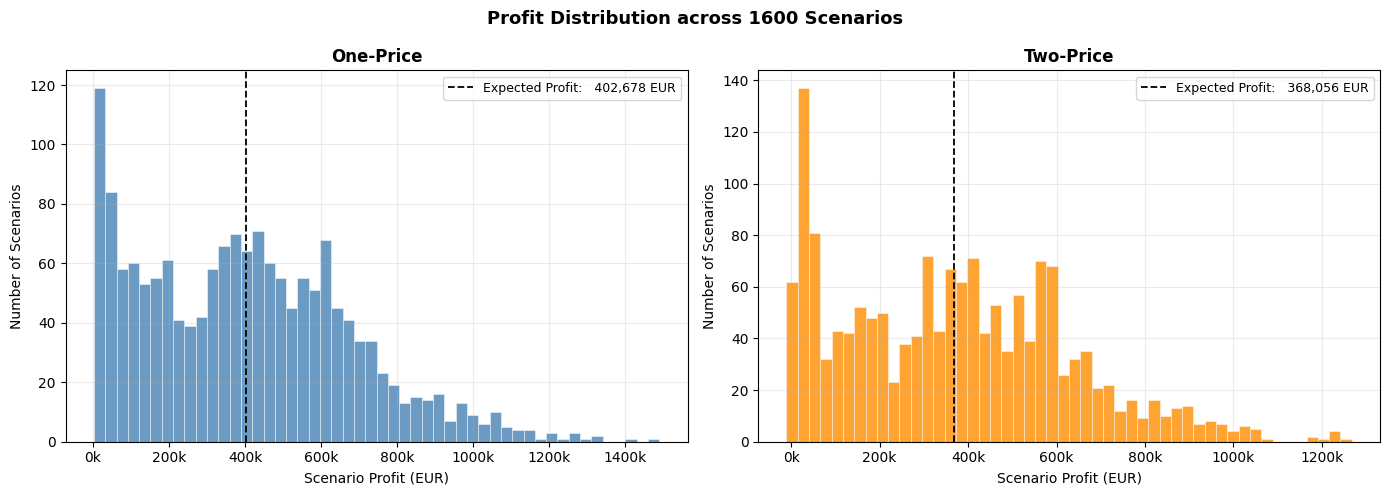

In [2]:
profits_one = pd.read_csv(RESULTS_DIR / "Task_1_1/profit_scenario.csv")["profit_EUR"].values
profits_two = pd.read_csv(RESULTS_DIR / "Task_1_2/profit_scenario.csv")["profit_EUR"].values

schemes_12 = [
    ("One-Price", profits_one, "steelblue"),
    ("Two-Price", profits_two, "darkorange"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, profits, color) in zip(axes, schemes_12):
    ax.hist(profits, bins=50, color=color, alpha=0.8, edgecolor="white", linewidth=0.4)
    ax.axvline(profits.mean(),     color="black", linestyle="--", linewidth=1.3,
               label=f"Expected Profit:   {profits.mean():,.0f} EUR")
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Scenario Profit (EUR)")
    ax.set_ylabel("Number of Scenarios")
    ax.xaxis.set_major_formatter(fmt_k)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

fig.suptitle("Profit Distribution across 1600 Scenarios", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "profit_histogram.pdf", dpi=150, bbox_inches="tight")
plt.show()

## Task 1.1 & 1.2 Profit Distribution (CDF)

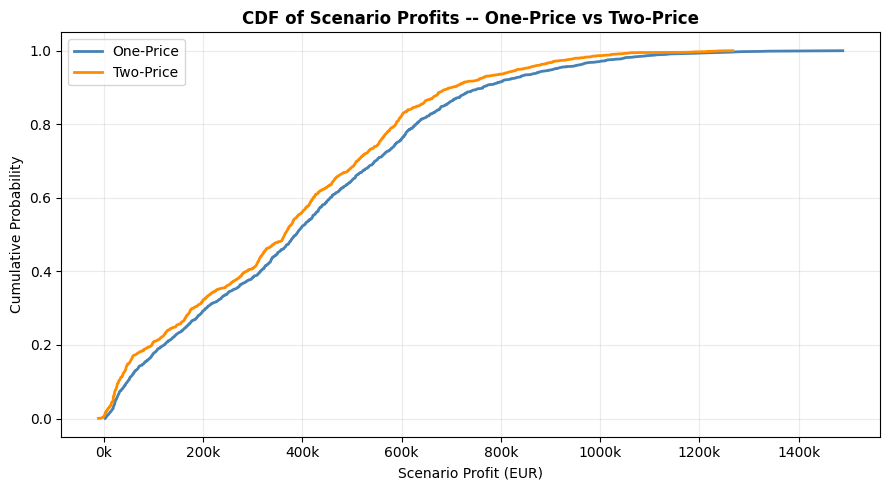

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
for label, profits, color in schemes_12:
    sorted_p = np.sort(profits)
    cdf = np.arange(1, len(sorted_p) + 1) / len(sorted_p)
    ax.plot(sorted_p, cdf, label=label, color=color, linewidth=2)

ax.set_xlabel("Scenario Profit (EUR)")
ax.set_ylabel("Cumulative Probability")
ax.set_title("CDF of Scenario Profits -- One-Price vs Two-Price", fontweight="bold")
ax.xaxis.set_major_formatter(fmt_k)
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "profit_cdf.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 1.3 â€” Cross-Validation: In-Sample vs Out-of-Sample Profit

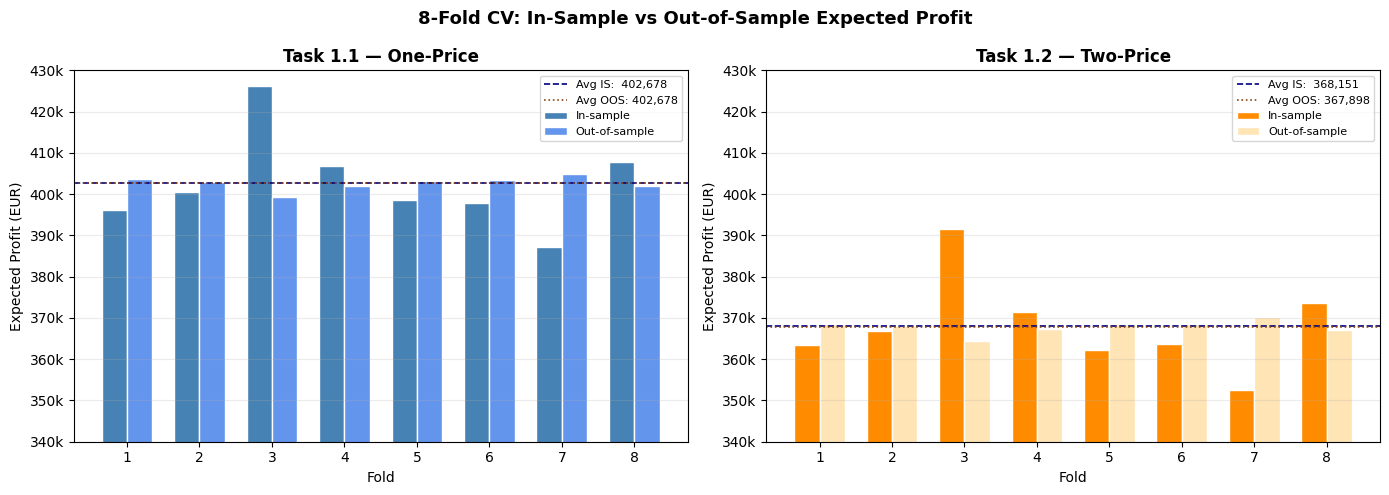

In [11]:
cv = pd.read_csv(RESULTS_DIR / "Task_1_3/cv_results.csv")

scheme_meta = {
    "one_price": ("Task 1.1 â€” One-Price", "steelblue",  "cornflowerblue"),
    "two_price": ("Task 1.2 â€” Two-Price", "darkorange", "moccasin"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (scheme, (label, color_is, color_oos)) in zip(axes, scheme_meta.items()):
    sub = cv[cv["scheme"] == scheme].sort_values("fold")
    x   = np.arange(len(sub))
    w   = 0.35
    ax.bar(x - w/2, sub["in_sample_profit"],     w, label="In-sample",     color=color_is,  edgecolor="white")
    ax.bar(x + w/2, sub["out_of_sample_profit"], w, label="Out-of-sample", color=color_oos, edgecolor="white")
    ax.axhline(sub["in_sample_profit"].mean(),     color="navy",       linestyle="--", linewidth=1.2,
               label=f"Avg IS:  {sub['in_sample_profit'].mean():,.0f}")
    ax.axhline(sub["out_of_sample_profit"].mean(), color="saddlebrown", linestyle=":",  linewidth=1.2,
               label=f"Avg OOS: {sub['out_of_sample_profit'].mean():,.0f}")
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Fold")
    ax.set_ylabel("Expected Profit (EUR)")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["fold"].values)
    ax.set_ylim(340_000, 430_000)
    ax.yaxis.set_major_formatter(fmt_k)
    ax.legend(fontsize=8)
    ax.grid(True, axis="y", alpha=0.25)

fig.suptitle("8-Fold CV: In-Sample vs Out-of-Sample Expected Profit", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cv_is_vs_oos.pdf", dpi=150, bbox_inches="tight")
plt.show()


## Task 1.4 -- Risk-Averse Efficient Frontier (E[€] vs CVaR)

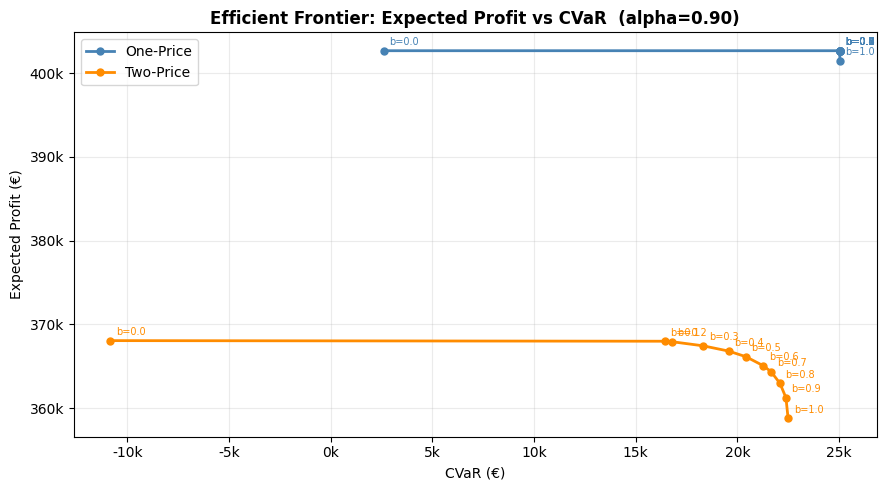

In [11]:
ef = pd.read_csv(RESULTS_DIR / "Task_1_4/efficient_frontier.csv")

fig, ax = plt.subplots(figsize=(9, 5))
for scheme, color, label in [
    ("one_price", "steelblue",  "One-Price"),
    ("two_price", "darkorange", "Two-Price"),
]:
    sub = ef[ef["scheme"] == scheme].sort_values("beta")
    ax.plot(sub["cvar"], sub["expected_profit"], color=color, linewidth=2,
            marker="o", markersize=5, label=label)
    for _, row in sub.iterrows():
        ax.annotate(f"b={row['beta']:.1f}",
                    xy=(row["cvar"], row["expected_profit"]),
                    xytext=(4, 4), textcoords="offset points",
                    fontsize=7, color=color)

ax.set_xlabel("CVaR (€)")
ax.set_ylabel("Expected Profit (€)")
ax.set_title("Efficient Frontier: Expected Profit vs CVaR  (alpha=0.90)", fontweight="bold")
ax.xaxis.set_major_formatter(fmt_k)
ax.yaxis.set_major_formatter(fmt_k)
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "efficient_frontier.pdf", dpi=150, bbox_inches="tight")
plt.show()

## Task 2.1 - Load profiles


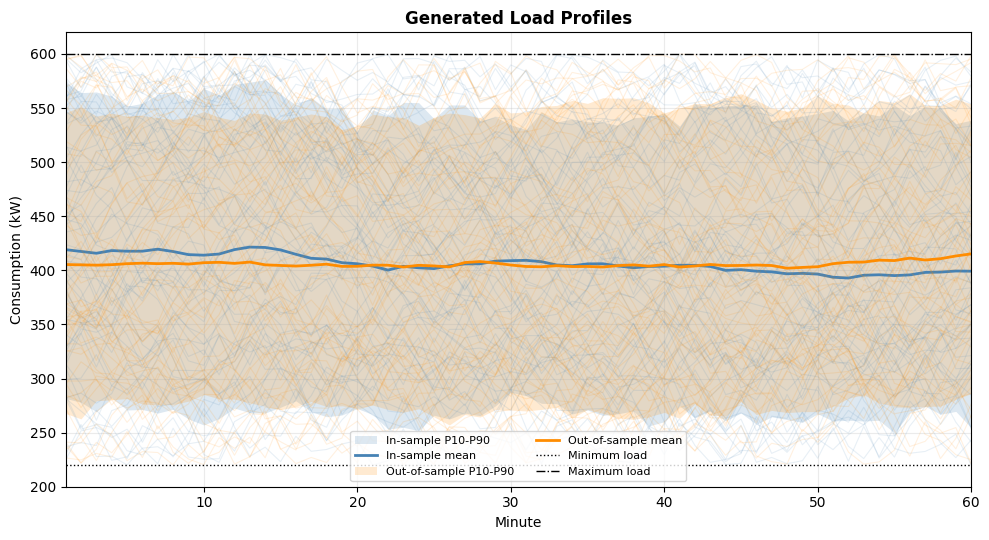

In [12]:
task21_dir = RESULTS_DIR / "Task_2_1"
profiles_df = pd.read_csv(task21_dir / "load_profiles.csv")

MIN_LOAD = 220.0
MAX_LOAD = 600.0

minutes = np.sort(profiles_df["minute"].unique())


def profile_matrix(sample, value_col):
    return (
        profiles_df[profiles_df["sample"] == sample]
        .pivot(index="profile_id", columns="minute", values=value_col)
        .sort_index()
        .to_numpy()
    )


def profile_summary(matrix):
    return {
        "mean": matrix.mean(axis=0),
        "p10": np.percentile(matrix, 10, axis=0),
        "p90": np.percentile(matrix, 90, axis=0),
    }


def plot_profile_group(ax, matrix, label, color, max_profiles=60):
    for profile in matrix[:max_profiles]:
        ax.plot(minutes, profile, color=color, alpha=0.12, linewidth=0.8)

    summary = profile_summary(matrix)
    ax.fill_between(
        minutes,
        summary["p10"],
        summary["p90"],
        color=color,
        alpha=0.18,
        linewidth=0,
        label=f"{label} P10-P90",
    )
    ax.plot(minutes, summary["mean"], color=color, linewidth=2.0, label=f"{label} mean")


in_load = profile_matrix("in_sample", "load_kW")
oos_load = profile_matrix("out_of_sample", "load_kW")

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_profile_group(ax, in_load, "In-sample", "steelblue")
plot_profile_group(ax, oos_load, "Out-of-sample", "darkorange")

ax.axhline(MIN_LOAD, color="black", linestyle=":", linewidth=1.0, label="Minimum load")
ax.axhline(MAX_LOAD, color="black", linestyle="-.", linewidth=1.0, label="Maximum load")
ax.set_title("Generated Load Profiles", fontweight="bold")
ax.set_xlabel("Minute")
ax.set_ylabel("Consumption (kW)")
ax.set_xlim(minutes[0], minutes[-1])
ax.set_ylim(MIN_LOAD - 20, MAX_LOAD + 20)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(task21_dir / "load_profiles.pdf", dpi=150, bbox_inches="tight")
plt.show()


## Task 2.3 - P-requirement sensitivity


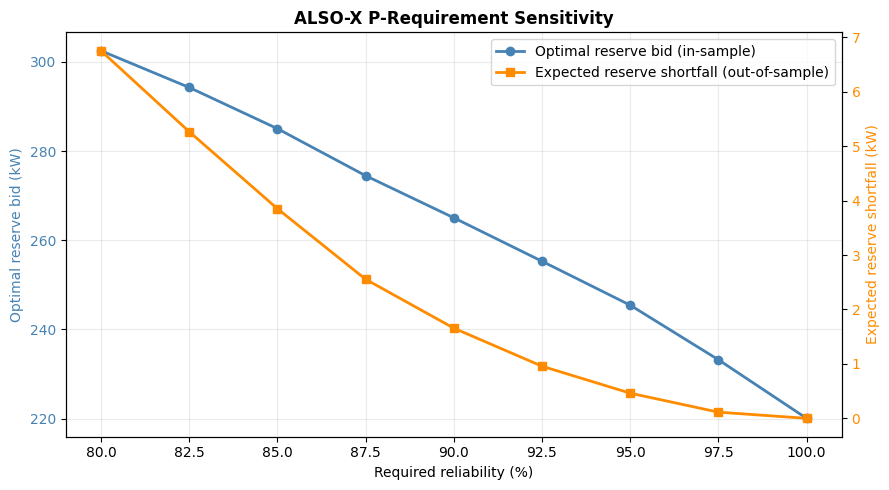

In [14]:
task23_dir = RESULTS_DIR / "Task_2_3"
sweep = pd.read_csv(task23_dir / "p_requirement_sweep.csv")

x = 100 * sweep["required_reliability"]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(
    x,
    sweep["c_up_kW"],
    color="steelblue",
    marker="o",
    linewidth=2,
    label="Optimal reserve bid (in-sample)",
)
ax1.set_xlabel("Required reliability (%)")
ax1.set_ylabel("Optimal reserve bid (kW)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(
    x,
    sweep["expected_shortfall_kW"],
    color="darkorange",
    marker="s",
    linewidth=2,
    label="Expected reserve shortfall (out-of-sample)",
)
ax2.set_ylabel("Expected reserve shortfall (kW)", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="best")
ax1.set_title("ALSO-X P-Requirement Sensitivity", fontweight="bold")
plt.tight_layout()
plt.savefig(task23_dir / "p_requirement_sensitivity.pdf", dpi=150, bbox_inches="tight")
plt.show()
